# Boundary conditions: paramagnetic slab in a uniform magnetic field

Explore which components of the magnetic field are **continuous** or **discontinuous** across the boundary of a material.

Griffiths gives the boundary conditions as
$$
B_\perp^{\text{outside}} - B_\perp^{\text{inside}} = 0
\qquad\text{(note: this is a scalar equation)}
$$
and
$$
\vec{B}_{\parallel}^{\text{outside}} - \vec{B}_{\parallel}^{\text{inside}}
= \mu_0\left(\vec{K}\times \hat{n}\right)
\qquad\text{(vector equation)}
$$

Where $\vec{B}$ is the total magnetic field (like always in this class) and $\vec{K}$ is the bound surface current.

We assume an **applied uniform** magnetic field (we do *not* model the source currents that create it).

In the example below, what does $\vec{K}$ look like?

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

plt.rcParams["figure.dpi"] = 120
mu0 = 4*np.pi*1e-7

## Model

We model an infinite slab occupying $|x|<a$.

Linear paramagnet:
$$
\mathbf{M}=\chi_m\mathbf{H},\qquad \mathbf{B}=\mu_0(\mathbf{H}+\mathbf{M})=\mu_0(1+\chi_m)\mathbf{H}=\mu\mathbf{H}.
$$
So $\mu_r = 1+\chi_m$ and $\mu = \mu_0\mu_r$.

The applied field is assumed uniform and **fixed tangential to the slab boundary** in this notebook.

In [2]:
# ------------------------------------------------------------
# Helper: piecewise-constant fields for an infinite slab
# ------------------------------------------------------------
def slab_fields(B0: float, chi_m: float, a: float, orientation: str):
    """Return (Bx_out, By_out, Bx_in, By_in) and matching H and M values.

    Slab is |x|<a. Outside is vacuum (mu=mu0). Inside has mu = mu0*(1+chi_m).

    Boundary conditions used (K_free = 0):
      - B_perp continuous
      - H_parallel continuous
    """
    mu_r = 1.0 + chi_m
    mu_in = mu0 * mu_r
    mu_out = mu0

    if orientation.lower().startswith("normal"):
        # Applied B along x (normal to boundary)
        # B_perp = Bx is continuous: Bx_in = Bx_out = B0
        Bx_out, By_out = B0, 0.0
        Bx_in,  By_in  = B0, 0.0

        # Then H differs because B = mu H
        Hx_out, Hy_out = Bx_out/mu_out, 0.0
        Hx_in,  Hy_in  = Bx_in/mu_in,  0.0

    else:
        # Applied B along y (tangential to boundary)
        # H_parallel = Hy is continuous: Hy_in = Hy_out
        # Outside: By_out = B0 = mu0 * Hy_out -> Hy_out = B0/mu0
        # Inside:  By_in  = mu_in * Hy_in = (mu0*mu_r)*(B0/mu0)=mu_r*B0
        Bx_out, By_out = 0.0, B0
        Bx_in,  By_in  = 0.0, mu_r*B0

        Hx_out, Hy_out = 0.0, By_out/mu_out
        Hx_in,  Hy_in  = 0.0, Hy_out  # continuous

    # M = chi_m * H inside, 0 outside
    Mx_out, My_out = 0.0, 0.0
    Mx_in,  My_in  = chi_m*Hx_in, chi_m*Hy_in

    out = {
        "mu_r": mu_r,
        "B_out": np.array([Bx_out, By_out], dtype=float),
        "B_in":  np.array([Bx_in,  By_in],  dtype=float),
        "H_out": np.array([Hx_out, Hy_out], dtype=float),
        "H_in":  np.array([Hx_in,  Hy_in],  dtype=float),
        "M_out": np.array([Mx_out, My_out], dtype=float),
        "M_in":  np.array([Mx_in,  My_in],  dtype=float),
    }
    return out


def fields_on_grid(x, y, a, vec_out, vec_in):
    """Return piecewise-constant vector field on a 2D meshgrid."""
    X, Y = np.meshgrid(x, y)
    inside = np.abs(X) < a
    Fx = np.where(inside, vec_in[0], vec_out[0])
    Fy = np.where(inside, vec_in[1], vec_out[1])
    return X, Y, Fx, Fy, inside


def unit_vectors_and_magnitude(Fx, Fy):
    mag = np.sqrt(Fx**2 + Fy**2)
    mag_safe = np.where(mag == 0, 1.0, mag)
    ux = Fx / mag_safe
    uy = Fy / mag_safe
    return ux, uy, mag

In [3]:
# =============================================================
# STUDENTS: set values here (then run the plotting cells below)
# =============================================================

# Geometry (slab is |x| < a)
a = 1.0

# Material (linear paramagnet)
chi_m = 0.8      # susceptibility (try 0.0, 0.2, 1.0)
mu_r = 1 + chi_m

# Applied magnetic field magnitude (assumed uniform, far away)
B0 = 1.0         # Tesla (any units are fine for the visualization)

# We will walk horizontally and look at the magnetic field components
# Here we set the height of the horizontal path
y0 = 0

# Plot controls
show_M = True
Nx, Ny = 410, 250        # sampling grid for plots
slice_points = 400       # resolution for slice plots


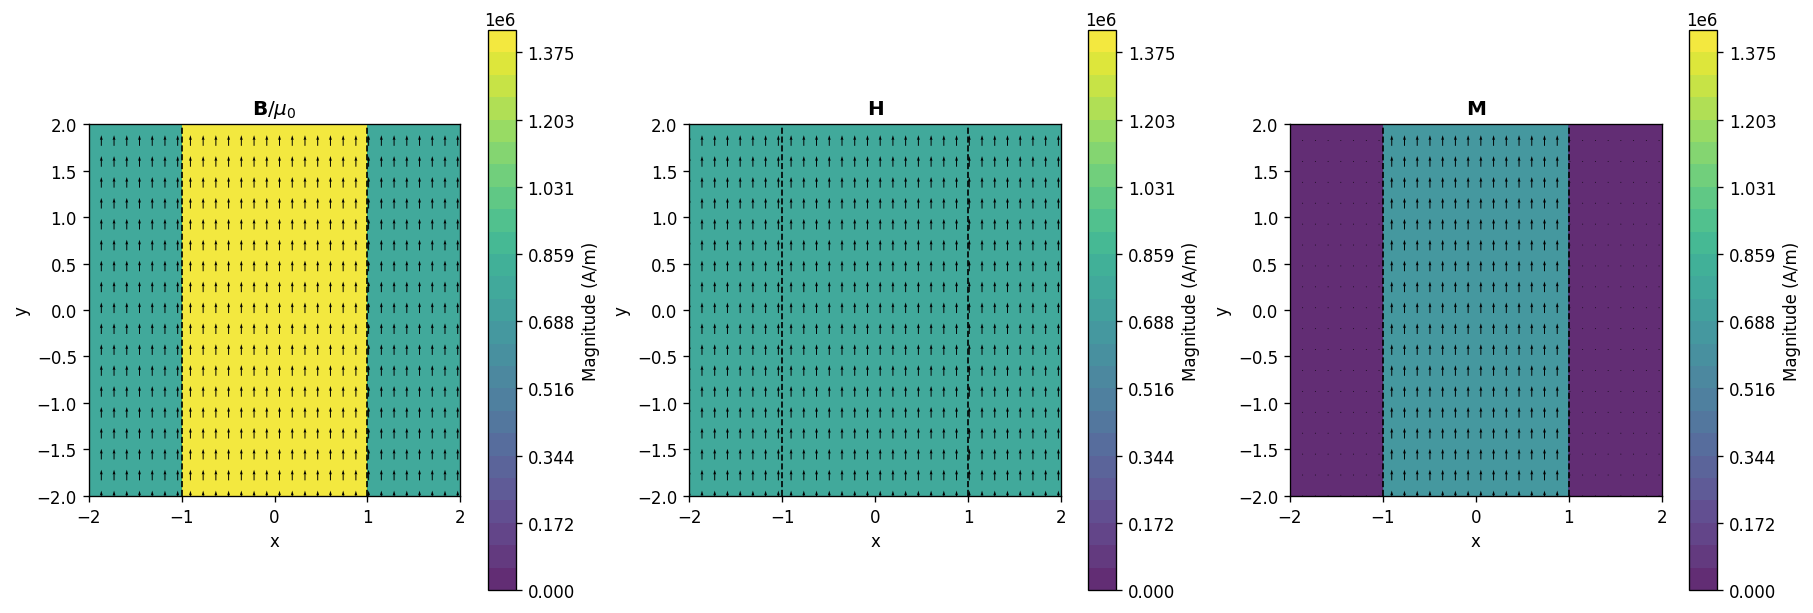

In [4]:
# ---------------------------------------------------------
# Geometry and grid
# ---------------------------------------------------------
x = np.linspace(-2*a, 2*a, Nx)
y = np.linspace(-2*a, 2*a, Ny)
X, Y = np.meshgrid(x, y)

inside = np.abs(X) < a

# ---------------------------------------------------------
# ASSUMED uniform applied field (fixed orientation)
# Applied field is TANGENTIAL to the slab boundary: along +y.
#
# With no free surface current (K_free = 0): H_t is continuous.
# ---------------------------------------------------------
# Outside: B = B0 y-hat -> H_out = B0/mu0 y-hat
H0 = B0 / mu0

# H field (continuous tangential component)
Hx = np.zeros_like(X)
Hy = np.full_like(X, H0)

# B field from H
Bx = mu0 * Hx
By = mu0 * Hy
By[inside] = mu0 * mu_r * Hy[inside]   # inside: B increases by mu_r

# Magnetization: M = chi_m H inside, 0 outside
Mx = np.zeros_like(X)
My = np.zeros_like(X)
My[inside] = chi_m * Hy[inside]

# ---------------------------------------------------------
# Convenience: plot B/mu0 instead of B
# (units A/m, directly comparable to H and M)
# ---------------------------------------------------------
Bmu_x = Bx / mu0
Bmu_y = By / mu0

def unit_vectors(Fx, Fy):
    mag = np.sqrt(Fx**2 + Fy**2)
    mag_safe = np.where(mag == 0, 1.0, mag)
    return Fx/mag_safe, Fy/mag_safe, mag

Bmu_x_u, Bmu_y_u, Bmu_mag = unit_vectors(Bmu_x, Bmu_y)
Hx_u,   Hy_u,   Hmag     = unit_vectors(Hx, Hy)
Mx_u,   My_u,   Mmag     = unit_vectors(Mx, My)

# ---------------------------------------------------------
# Shared contour color scale across ALL three panels
# ---------------------------------------------------------
global_max = max(Bmu_mag.max(), Hmag.max(), Mmag.max())
norm = Normalize(vmin=0.0, vmax=global_max)
levels = np.linspace(0.0, global_max, 26)

# ---------------------------------------------------------
# 1x3 plot: B/mu0, H, M
# Vectors: unit vectors, single color
# Strength: shown with a superimposed contour map of magnitude
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

panels = [
    (r"$\mathbf{B}/\mu_0$", Bmu_x_u, Bmu_y_u, Bmu_mag),
    (r"$\mathbf{H}$",       Hx_u,    Hy_u,    Hmag),
    (r"$\mathbf{M}$",       Mx_u,    My_u,    Mmag),
]

for ax, (title, Ux, Uy, Mag) in zip(axes, panels):
    cf = ax.contourf(X, Y, Mag, levels=levels, norm=norm, alpha=0.85)
    plt.colorbar(cf, ax=ax, label="Magnitude (A/m)")

    step = max(1, Nx//28)
    ax.quiver(X[::step, ::step], Y[::step, ::step],
              Ux[::step, ::step], Uy[::step, ::step],
              color="k", pivot="middle", scale=35)

    ax.axvline(-a, color='k', linestyle='--', linewidth=1)
    ax.axvline(a,  color='k', linestyle='--', linewidth=1)

    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="box")

    # Always show the full computed range
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(y.min(), y.max())

plt.show()

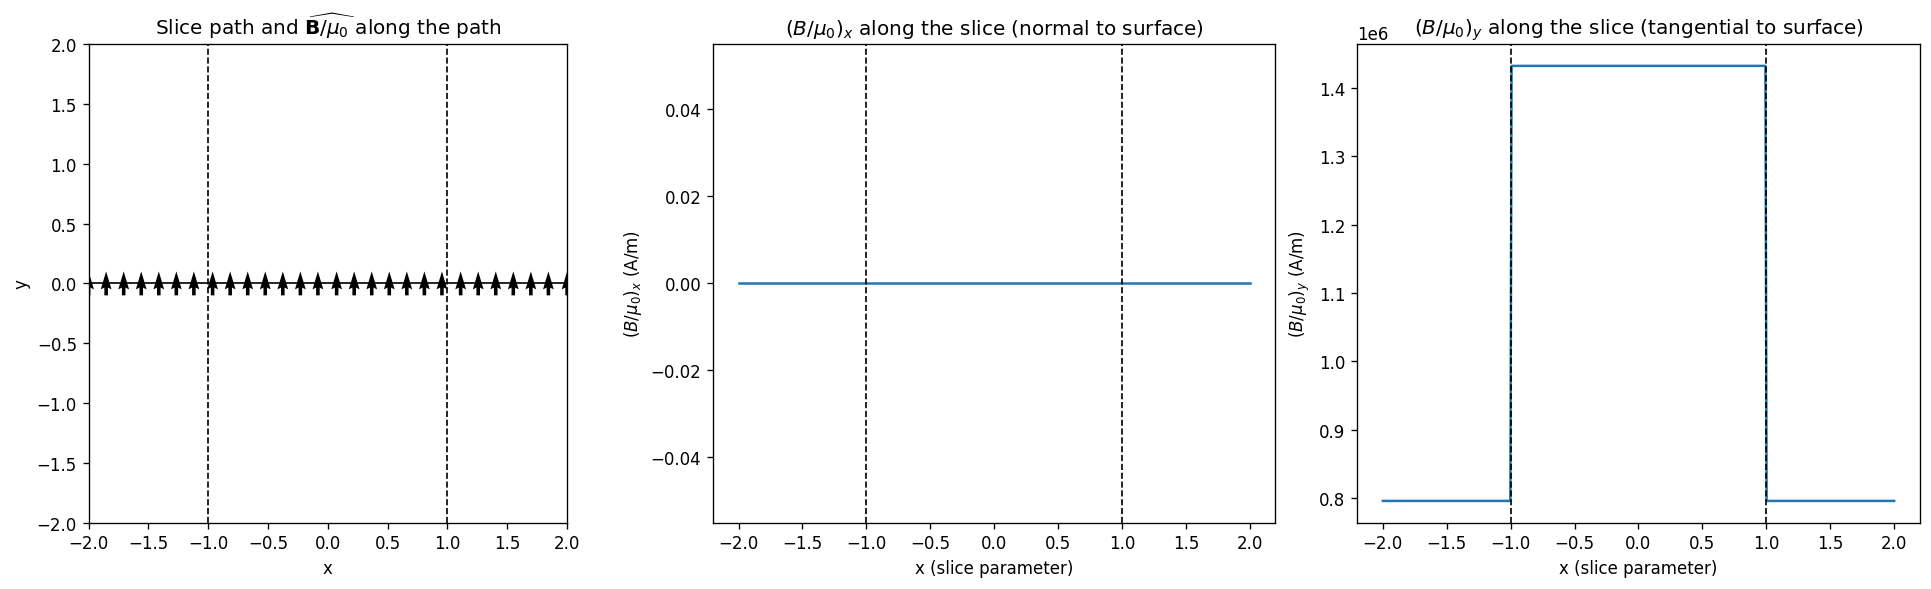

In [5]:
# ---------------------------------------------------------
# Slice plots (like the dielectric notebook)
# 1x3: (1) slice path + vectors along it
#      (2) (B/mu0)_perp along the path   (perpendicular to surface normal x)
#      (3) (B/mu0)_parallel along the path (parallel to surface, along y)
#
# Slice path is fixed to be HORIZONTAL: y = y0
# ---------------------------------------------------------

# Horizontal slice: path crosses the slab boundaries
Xs = x
Ys = np.full_like(x, y0)
xlabel = "x (slice parameter)"
vline_positions = [-a, a]

# Choose nearest row to y0
iy0 = np.argmin(np.abs(y - y0))

# Use B/mu0 instead of B
Bmu_x = Bx / mu0
Bmu_y = By / mu0

Bmu_x_s = Bmu_x[iy0, :]
Bmu_y_s = Bmu_y[iy0, :]
Bmu_mag_s = np.sqrt(Bmu_x_s**2 + Bmu_y_s**2)

# Components relative to the slab surface (surface normal is x-hat)
Bmu_perp = Bmu_x_s
Bmu_parallel = Bmu_y_s

# Unit vectors along the path for panel (1)
mag_safe = np.where(Bmu_mag_s == 0, 1.0, Bmu_mag_s)
Ux_s = Bmu_x_s / mag_safe
Uy_s = Bmu_y_s / mag_safe

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

# (1) Path plot
ax0 = axes[0]
ax0.set_title(r"Slice path and $\widehat{\mathbf{B}/\mu_0}$ along the path")
ax0.set_xlabel("x")
ax0.set_ylabel("y")
ax0.set_aspect("equal", adjustable="box")

# Always show full computed range
ax0.set_xlim(x.min(), x.max())
ax0.set_ylim(y.min(), y.max())

ax0.axvline(-a, color='k', linestyle='--', linewidth=1)
ax0.axvline(a,  color='k', linestyle='--', linewidth=1)

ax0.plot(Xs, Ys, 'k-', linewidth=1)

n_arrows = 28
idx = np.linspace(0, len(x)-1, n_arrows).astype(int)
ax0.quiver(Xs[idx], Ys[idx], Ux_s[idx], Uy_s[idx],
           color='k', pivot='middle', scale=20)

# (2) Perpendicular component
ax1 = axes[1]
ax1.set_title(r"$(B/\mu_0)_x$ along the slice (normal to surface)")
ax1.plot(x, Bmu_x_s)
ax1.set_xlabel(xlabel)
ax1.set_ylabel(r"$(B/\mu_0)_x$ (A/m)")
for xp in vline_positions:
    ax1.axvline(xp, color='k', linestyle='--', linewidth=1)

# (3) Parallel component
ax2 = axes[2]
ax2.set_title(r"$(B/\mu_0)_y$ along the slice (tangential to surface)")
ax2.plot(x, Bmu_y_s)
ax2.set_xlabel(xlabel)
ax2.set_ylabel(r"$(B/\mu_0)_y$ (A/m)")
for xp in vline_positions:
    ax2.axvline(xp, color='k', linestyle='--', linewidth=1)

plt.show()